# LAB ML 3 — Clustering (SOLUTION)

## PROBLEM STATEMENT (from `lab3_clustering_handout.ipynb`):

We have the same 360 students from Lab 2, but we *throw away the grade label*. All
we have is their study habits. Can we still find meaningful groups?

This is **unsupervised learning**: no target, no right answer given to the model.
We ask `K-Means` to discover structure by grouping students who look similar. Once
it has found the clusters, we sneak a peek at the hidden grades and find out
whether the discovered groups correspond to real grade patterns.

Tasks (verbatim from the handout, plus the implicit T4 elbow/silhouette task that
the handout's summary promises):

- **T1** — Fit K-Means with `k=3` on the two features `study_hours_per_week` and
  `prior_math_grade`. Save labels and centroids in original units.
- **T2** — Fit K-Means with `k=3` on all 6 habit features. Describe each cluster by
  its centroid. Reveal hidden grade differences.
- **T3** — Refit on the 2-feature data with `k=2, 3, 5` and store the models in a
  dict keyed by `k`. Compare inertia and silhouette.
- **T4 (implicit)** — Sweep `k = 1..10`, plot the **elbow** curve (inertia vs `k`)
  and the **silhouette** curve (mean silhouette vs `k`). Pick `k` with evidence.
- **T5** — Fill in YOUR study habits, scale them with the T2 scaler, predict your
  cluster with `kmeans6`, and read off the cluster's typical grade.
- **T6 (bonus)** — Implement K-Means from scratch in one short loop and land within
  a couple of inertia points of sklearn's answer.

## MENTAL MODEL (one-line analogy):

**K party-hosts each claim the nearest guests, then re-arrange until nobody wants
to switch.** Pick `K` host-spots. Every guest joins the closest host. Each host
then moves to the geometric centre of their guests. Repeat. When no guest changes
host, the party is settled — the hosts are the **centroids**, the guests around
each host are a **cluster**. (This is consistent with the analogy used in the
L12 — Clustering lecture chapter §2.)

## REFERENCES:

- **L12 — Clustering** (`study/lectures/L12-Clustering.md`):
  - §3 *Core Concepts* — cluster, centroid, intra/inter-cluster distance, partitional
    vs hierarchical, K-means objective (within-cluster sum-of-squares = inertia).
  - §4 *Algorithms* — K-means iteration (assign + update), bisecting K-means.
  - §6 *Common Pitfalls* — random init traps, unscaled features, picking `k`.
  - L12 does **not** formally introduce K-means++ initialisation or the silhouette
    score; this lab introduces them.
- **L10 — Intro to ML**: defines *unsupervised learning* and *clustering* as a task.
- Glossary terms: `K-means clustering`, `Centroid (cluster centroid)`, `Clustering`,
  `Unsupervised learning`, `Inertia (within-cluster sum-of-squares)`,
  `Elbow method`, `Silhouette score`, `K-means++` (the last three are introduced by
  this lab — see `study/_shared/glossary.md`).

## HOW TO ADAPT THIS FOR DIFFERENT QUESTION VARIANTS:

Every adjustable parameter is a `# KNOB:` block in the cell where it first appears.
The cells are designed so that flipping a KNOB and re-running from that cell onward
is enough — you should never have to edit a function body.

1. **"Refit with a different `K`" (e.g. `K=4`, `K=7`)** — for the 6-feature fit
   (T2, the grade-reveal heatmap, the T5 self-cluster), change `K_PRIMARY`. For
   the 2-feature fit (T1, the T6 from-scratch loop on the same 2-feature data),
   change `K_T1`. For the T3 side-by-side comparison, edit `K_GRID_T3`. For the
   T4 elbow + silhouette sweep, edit `K_GRID_T4`. **The T4 silhouette-argmax
   recommendation is computed over `K_GRID_T4` and is independent of
   `K_PRIMARY` — flipping `K_PRIMARY` does NOT change the recommendation.**
2. **"Use a different feature pair"** — change `FEATURE_PAIR_T1` in the T1 cell.
   `(study_hours_per_week, prior_math_grade)` is the default; try
   `(attendance_rate_pct, exercises_completed)` or `(sleep_hours, study_hours_per_week)`.
   The 2-D scatter, the side-by-side k-sweep plot, and the from-scratch loop all
   pick up the new pair.
3. **"Switch initialisation scheme: k-means++ vs random"** — change `INIT_SCHEME`
   (`'k-means++'` or `'random'`). The T1, T2, and T3 KMeans calls all read it.
   Watch inertia and silhouette change — random init usually loses by a few points
   on inertia and is more sensitive to `N_INIT`.
4. **"Re-run with N_INIT = 1" (no restart insurance)** — change `N_INIT`. With
   `N_INIT=1` and `INIT_SCHEME='random'` you can occasionally reproduce a poor
   local optimum; that is the textbook K-means failure mode.
5. **"Use a different random seed"** — change `RANDOM_STATE`. Affects every fit.
6. **"Set max_iter"** — `MAX_ITER` lower-bound stress-test: set it to 1 to see
   what K-means produces after a single pass; set it to 300 (default) to converge.
7. **"Compare a different k-grid in T4"** — change `K_GRID_T4` (default `range(1, 11)`).
   The elbow + silhouette curves are computed from this list.
8. **"What's my cluster?"** (T5) — change `MY_PROFILE`. Re-run the T5 reveal cell.

## OUTPUTS WHEN RUN:

Running every cell top-to-bottom produces, in order: a warm-up scatter on baked
blobs; the dataset shape line; six exploratory scatters and a `.describe()` table;
T1's three-cluster scatter with centroids; T2's six-feature heatmap of cluster
profiles and the *grade-spread* number; T3's side-by-side k=2/3/5 plots; T4's
two-panel elbow + silhouette curves with a recommended `k`; T5's personalised
cluster name + typical grade; T6's from-scratch inertia curve matched against
sklearn. Last cell prints a `SOLUTION COMPLETE` banner.

## ENTRY POINT: yes

Notebooks are always entry points. Run with:

```powershell
py -3.12 -m jupyter nbconvert --to notebook --execute lab3_clustering_solution.ipynb --output lab3_clustering_solution.executed.ipynb
```

## Global KNOBs — change these before re-running cells below

Everything that affects the result lives here. The exam-prep convention is:
*don't edit function bodies; flip a KNOB and re-run.*

In [1]:
# KNOB: RANDOM_STATE (default=42, range=any int)
#   What it does: seed for K-means initial centroid placement and the StandardScaler
#                 fit (the scaler itself is deterministic; the seed is for KMeans).
#   Effect: changes which local optimum is reached on a given fit. Holding everything
#           else fixed, two different seeds can produce slightly different labellings
#           and inertia.
#   Exam variants: 42 (default, matches the handout's sanity-check expectations),
#                  0/7/123 (use a different seed and report whether your inertia
#                  changed by more than 1%).
RANDOM_STATE = 42

# KNOB: K_T1 (default=3, allowed=any int >= 2)
#   What it does: number of clusters in T1 (2-feature fit).
#   Effect: small K (=2) merges archetypes along a single axis; large K (>=5) splits
#           archetypes into sub-groups that don't have a clean interpretation.
#   Exam variants: 2 / 3 (default) / 4 / 5. Also drives T6 (the from-scratch
#                  loop) because T6 fits on the same 2-feature data.
K_T1 = 3

# KNOB: K_PRIMARY (default=3, allowed=any int >= 2)
#   What it does: the 'main' K used by T2 (all 6 features) and T5 (self-
#                 classification, which predicts on the kmeans6 model). It does
#                 NOT affect T1 (uses K_T1), T3 (uses K_GRID_T3), T4 (uses
#                 K_GRID_T4 — the silhouette recommendation is independent of
#                 K_PRIMARY), or T6 (uses K_T1 because T6 fits on the 2-feature
#                 data). This is what an exam variant 'now use K=4' should target
#                 if the variant is about the 6-feature fit.
#   Effect: with K=3 K-means recovers the three baked archetypes; K=2 collapses
#           middle+light effort; K=4+ over-splits the achievers.
#   Exam variants: 2 / 3 (default) / 4 / 5.
K_PRIMARY = 3

# KNOB: FEATURE_PAIR_T1 (default=('study_hours_per_week', 'prior_math_grade'))
#   What it does: which two features T1 / T3 / T6 use for the 2-D fit and plot.
#   Effect: different pairs separate students by different axes. The default pair is
#           the most discriminative; sleep-vs-programming barely separates anything.
#   Exam variants: ('attendance_rate_pct', 'exercises_completed'),
#                  ('sleep_hours', 'study_hours_per_week'),
#                  ('prior_programming_years', 'prior_math_grade').
FEATURE_PAIR_T1 = ('study_hours_per_week', 'prior_math_grade')

# KNOB: K_GRID_T3 (default=[2, 3, 5])
#   What it does: the three K values T3 lays out side-by-side on the 2-D fit.
#   Effect: lets the reader see under-clustering vs the right K vs over-splitting in
#           one figure. Any three positive ints >=2 work.
#   Exam variants: [2, 3, 4], [2, 4, 6], [3, 5, 8].
K_GRID_T3 = [2, 3, 5]

# KNOB: K_GRID_T4 (default=range(1, 11))
#   What it does: the K values evaluated for the elbow + silhouette curves.
#   Effect: too narrow and the elbow isn't visible; too wide and runtime grows. The
#           default 1..10 is the standard textbook range.
#   Exam variants: range(2, 8) (faster, no inertia-of-1-cluster baseline),
#                  range(1, 16) (wider sweep to confirm silhouette never rebounds).
K_GRID_T4 = list(range(1, 11))

# KNOB: INIT_SCHEME (default='k-means++', allowed={'k-means++', 'random'})
#   What it does: how the initial centroids are placed BEFORE the assign/update loop.
#   Effect: 'k-means++' spreads the seeds far apart (one good run usually suffices);
#           'random' picks N_INIT independent random starts and keeps the best.
#           Random init is more variance-prone and may need a larger N_INIT to match
#           k-means++.
#   Exam variants: ask for both, compare inertia and silhouette — typically
#                  k-means++ is equal or better at the same N_INIT.
INIT_SCHEME = 'k-means++'

# KNOB: N_INIT (default=10, range=1..50)
#   What it does: number of independent restarts; sklearn keeps the best by inertia.
#   Effect: more restarts = better odds of hitting the global optimum, linear cost.
#           With N_INIT=1 you can occasionally reproduce a textbook poor local
#           optimum, especially when paired with INIT_SCHEME='random'.
#   Exam variants: 1 (stress-test stability), 10 (default), 50 (overkill but safe).
N_INIT = 10

# KNOB: MAX_ITER (default=300, range=1..10000)
#   What it does: hard cap on assign/update iterations per restart.
#   Effect: 300 is sklearn's default and is plenty for this data. Setting MAX_ITER=1
#           shows what K-means looks like after a single Lloyd step (centroids haven't
#           moved much beyond their initial positions).
#   Exam variants: 1 (educational), 300 (default), 3000 (over-budget; identical
#                  result because convergence happens long before).
MAX_ITER = 300

print('KNOBs loaded.',
      f'K_T1={K_T1},', f'K_PRIMARY={K_PRIMARY},',
      f'FEATURE_PAIR_T1={FEATURE_PAIR_T1},',
      f'INIT_SCHEME={INIT_SCHEME!r},', f'N_INIT={N_INIT}')

KNOBs loaded. K_T1=3, K_PRIMARY=3, FEATURE_PAIR_T1=('study_hours_per_week', 'prior_math_grade'), INIT_SCHEME='k-means++', N_INIT=10


## Imports and plot theme

Same setup as the handout. The solution adds nothing here — the handout cell is
already complete.

In [2]:
# Imports and plot theme — run once, then forget about this cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'blue':   '#3563E9',
    'teal':   '#0F9D8A',
    'orange': '#F28E2B',
    'red':    '#D64545',
    'gold':   '#B88700',
    'slate':  '#5F6C7B',
    'navy':   '#264653',
    'purple': '#8E6BB5',
}

CLUSTER_PALETTE = [COLORS['teal'], COLORS['orange'], COLORS['purple'],
                   COLORS['blue'], COLORS['gold'], COLORS['red'],
                   COLORS['navy'], COLORS['slate']]

print('Setup complete. Ready to discover student groups.')

Setup complete. Ready to discover student groups.


## 0. Warm-up — K-Means in 3 lines

K-means on three obviously-separable baked blobs. Demonstrates the *party-hosts*
analogy in two dimensions where you can literally see the centroids and the
clusters they own.

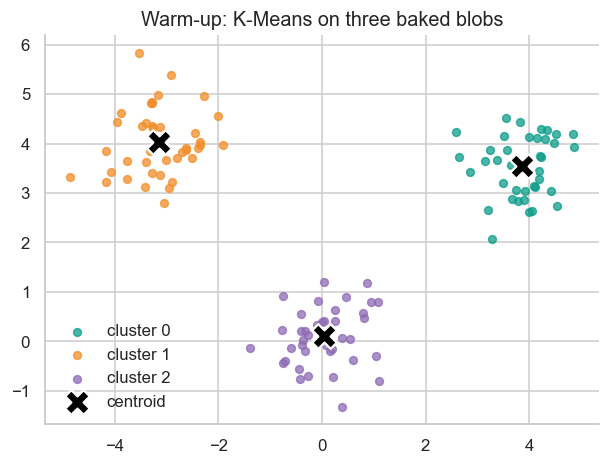

In [3]:
# --- Intuition demo ---

rng = np.random.default_rng(0)
centers_true = np.array([[0.0, 0.0], [4.0, 3.5], [-3.0, 4.0]])
blobs = np.vstack([c + rng.normal(0, 0.6, size=(40, 2)) for c in centers_true])

demo_model = KMeans(n_clusters=3, random_state=0, n_init=10)
demo_model.fit(blobs)
demo_labels = demo_model.labels_
demo_centers = demo_model.cluster_centers_

fig, ax = plt.subplots(figsize=(6.5, 4.6))
for i in range(3):
    pts = blobs[demo_labels == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=26, alpha=0.75,
               color=CLUSTER_PALETTE[i], label=f'cluster {i}')
ax.scatter(demo_centers[:, 0], demo_centers[:, 1], s=260, marker='X',
           color='black', edgecolor='white', linewidth=1.5, label='centroid')
ax.set_title('Warm-up: K-Means on three baked blobs')
ax.legend()
plt.show()

## 1. The student dataset

Same dataset generator as the handout — 360 students, three baked archetypes,
the same six visible habit features and three hidden columns (`final_score`,
`final_grade`, `true_archetype`).

In [4]:
# --- Build the dataset. The generator is self-contained. ---

DANISH_SCALE = np.array([-3, 0, 2, 4, 7, 10, 12], dtype=float)

def snap_to_danish(score):
    """Round each score to the nearest Danish grade in {-3, 0, 2, 4, 7, 10, 12}."""
    score = np.asarray(score, dtype=float)
    return DANISH_SCALE[np.argmin(np.abs(score[..., None] - DANISH_SCALE), axis=-1)]

# KNOB: N_STUDENTS (default=360, range=any int >= 50)
#   What it does: how many synthetic students the generator produces.
#   Effect: smaller N is faster but noisier; the three archetypes need at least ~50
#           students each to separate cleanly.
#   Exam variants: 200 (quick), 360 (default), 1000 (smoother profiles).
N_STUDENTS = 360

# KNOB: DATA_SEED (default=42, range=any int)
#   What it does: seed for the dataset generator. Different from RANDOM_STATE
#                 (which seeds K-means itself).
#   Effect: re-rolls every per-student value while keeping the three archetypes.
#   Exam variants: 1 / 42 / 2024 — use to demonstrate that the elbow/silhouette
#                  conclusions don't depend on a single sample.
DATA_SEED = 42

def make_student_profiles(n_students=N_STUDENTS, random_state=DATA_SEED):
    rng = np.random.default_rng(random_state)
    # Three baked archetypes with fixed mixing proportions.
    archetype = rng.choice([0, 1, 2], size=n_students, p=[0.35, 0.40, 0.25])
    study = np.empty(n_students); attend = np.empty(n_students)
    prior_math = np.empty(n_students); sleep = np.empty(n_students)
    exercises = np.empty(n_students, dtype=int); prog = np.empty(n_students)

    # Archetype 0 — 'Dedicated achievers'
    m = archetype == 0; k = m.sum()
    study[m]      = rng.normal(12.0, 2.0, k)
    attend[m]     = rng.normal(92.0, 4.5, k)
    prior_math[m] = rng.choice([7, 10, 12], size=k, p=[0.30, 0.50, 0.20])
    sleep[m]      = rng.normal(7.3, 0.5, k)
    exercises[m]  = rng.binomial(10, 0.82, k)
    prog[m]       = rng.exponential(2.2, k)

    # Archetype 1 — 'Moderate middle'
    m = archetype == 1; k = m.sum()
    study[m]      = rng.normal(7.5, 1.8, k)
    attend[m]     = rng.normal(82.0, 7.0, k)
    prior_math[m] = rng.choice([4, 7, 10], size=k, p=[0.30, 0.55, 0.15])
    sleep[m]      = rng.normal(7.0, 0.9, k)
    exercises[m]  = rng.binomial(10, 0.50, k)
    prog[m]       = rng.exponential(1.0, k)

    # Archetype 2 — 'Light effort'
    m = archetype == 2; k = m.sum()
    study[m]      = rng.normal(3.8, 1.8, k)
    attend[m]     = rng.normal(68.0, 9.0, k)
    prior_math[m] = rng.choice([-3, 0, 2, 4], size=k, p=[0.15, 0.30, 0.35, 0.20])
    sleep[m]      = rng.normal(6.3, 1.2, k)
    exercises[m]  = rng.binomial(10, 0.25, k)
    prog[m]       = rng.exponential(0.6, k)

    # Clip everything into realistic ranges.
    study      = np.clip(study, 0.5, 20.0)
    attend     = np.clip(attend, 40.0, 100.0)
    sleep      = np.clip(sleep, 3.0, 10.0)
    prog       = np.clip(prog, 0.0, 6.0)
    prior_math = prior_math.astype(int)

    # Final score follows the same formula as Lab 2 — grades are a by-product of
    # habits (plus noise). K-means never sees this column; we use it for the reveal.
    score = (-3.0
             + 0.45 * study
             + 0.025 * attend
             + 0.35 * prior_math
             - 0.30 * (sleep - 7.2) ** 2
             + 0.18 * exercises
             + 0.30 * prog
             + rng.normal(0.0, 1.0, n_students))
    score = np.clip(score, -3.0, 12.0)

    df = pd.DataFrame({
        'study_hours_per_week':     np.round(study, 1),
        'attendance_rate_pct':      np.round(attend, 1),
        'prior_math_grade':         prior_math,
        'sleep_hours':              np.round(sleep, 1),
        'exercises_completed':      exercises,
        'prior_programming_years':  np.round(prog, 1),
        'final_score':              np.round(score, 2),                       # hidden
        'final_grade':              snap_to_danish(score).astype(int),         # hidden
        'true_archetype':           archetype,                                 # hidden
    })
    return df

FEATURE_COLS = [
    'study_hours_per_week',
    'attendance_rate_pct',
    'prior_math_grade',
    'sleep_hours',
    'exercises_completed',
    'prior_programming_years',
]
HIDDEN_COLS = ['final_score', 'final_grade', 'true_archetype']

df = make_student_profiles()
print(f'Dataset shape: {df.shape}')
print('Columns K-Means may use:', FEATURE_COLS)
print('Columns we keep hidden: ', HIDDEN_COLS)
df.head()

Dataset shape: (360, 9)
Columns K-Means may use: ['study_hours_per_week', 'attendance_rate_pct', 'prior_math_grade', 'sleep_hours', 'exercises_completed', 'prior_programming_years']
Columns we keep hidden:  ['final_score', 'final_grade', 'true_archetype']


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years,final_score,final_grade,true_archetype
0,3.4,93.7,2,5.0,2,0.9,-1.44,0,2
1,6.1,88.8,4,7.7,2,1.8,3.63,4,1
2,2.5,71.3,2,4.8,2,0.0,0.41,0,2
3,9.8,92.6,4,5.5,4,1.7,6.03,7,1
4,10.8,92.8,10,6.2,8,6.0,10.85,10,0


Summary (just the feature columns K-Means will see):


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years
count,360.00,360.00,360.00,360.0,360.00,360.00
mean,8.09,82.07,6.18,6.9,5.53,1.28
std,3.66,11.15,3.81,1.0,2.61,1.35
min,0.50,48.60,-3.00,3.0,0.00,0.00
25%,5.10,73.85,4.00,6.4,3.00,0.30
50%,7.70,84.55,7.00,7.0,6.00,0.80
75%,11.10,90.75,10.00,7.5,8.00,1.80
max,16.70,100.00,12.00,9.6,10.00,6.00


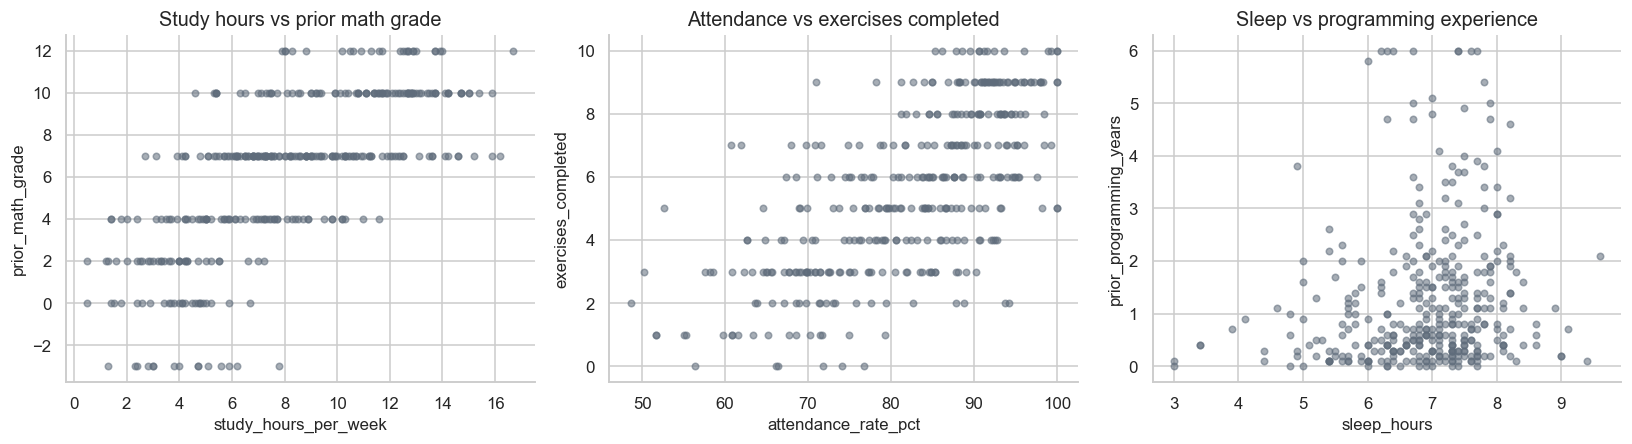

In [5]:
# --- Quick look at the features. ---

print('Summary (just the feature columns K-Means will see):')
display(df[FEATURE_COLS].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(df['study_hours_per_week'], df['prior_math_grade'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[0].set_xlabel('study_hours_per_week'); axes[0].set_ylabel('prior_math_grade')
axes[0].set_title('Study hours vs prior math grade')

axes[1].scatter(df['attendance_rate_pct'], df['exercises_completed'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[1].set_xlabel('attendance_rate_pct'); axes[1].set_ylabel('exercises_completed')
axes[1].set_title('Attendance vs exercises completed')

axes[2].scatter(df['sleep_hours'], df['prior_programming_years'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[2].set_xlabel('sleep_hours'); axes[2].set_ylabel('prior_programming_years')
axes[2].set_title('Sleep vs programming experience')

plt.tight_layout(); plt.show()

## 2. T1 — K-Means with 2 features (SOLVED)

### Why this is the right approach

Two features means we can literally plot the centroids and the cluster colours on
a 2-D scatter and visually check whether K-means did something sensible.

The three procedural decisions:

1. **Scale** with `StandardScaler` so that the larger numeric range of
   `study_hours_per_week` (0–20) doesn't drown out `prior_math_grade` (−3–12) in
   the Euclidean distance.
2. **Fit on scaled, plot on raw.** We fit the model where distances are fair,
   then call `scaler.inverse_transform` on the cluster centres so the scatter
   plot's axes read in their original units.
3. **`n_init` + `random_state`.** `N_INIT` independent restarts + `RANDOM_STATE`
   for reproducibility — the two KNOBs declared at the top of the notebook.

### Intuition cell — raw vs scaled feature distribution

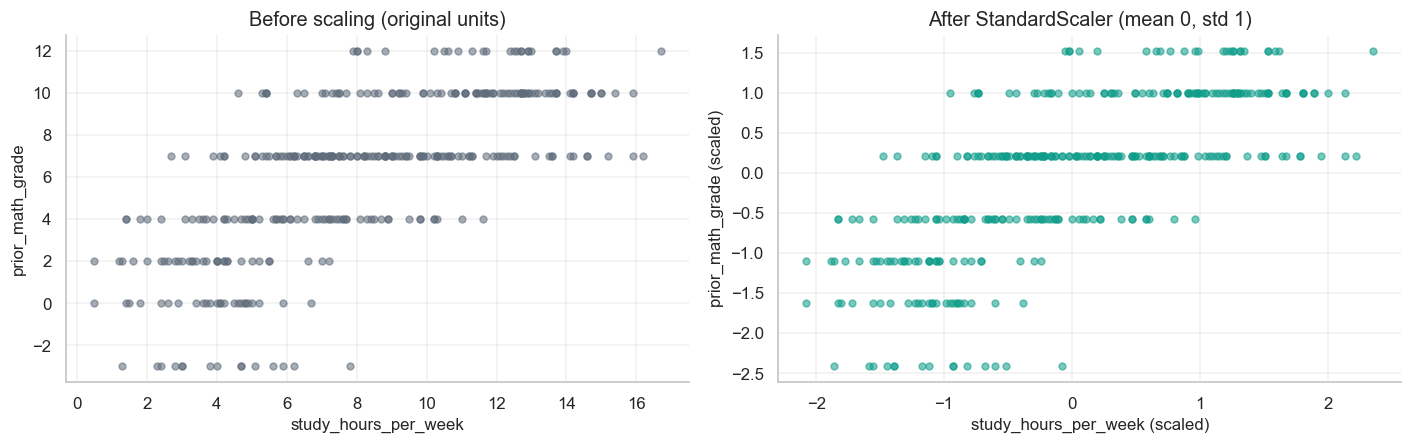

After scaling, both features have mean=0 and std=1.
  means: [-0. -0.]
  stds : [1. 1.]


In [6]:
# Intuition: show the same two features before and after scaling.

demo_feats = list(FEATURE_PAIR_T1)
X_demo_raw = df[demo_feats].values
X_demo_scaled = StandardScaler().fit_transform(X_demo_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(X_demo_raw[:, 0], X_demo_raw[:, 1], s=20, alpha=0.55,
                color=COLORS['slate'])
axes[0].set_title('Before scaling (original units)')
axes[0].set_xlabel(demo_feats[0]); axes[0].set_ylabel(demo_feats[1])

axes[1].scatter(X_demo_scaled[:, 0], X_demo_scaled[:, 1], s=20, alpha=0.55,
                color=COLORS['teal'])
axes[1].set_title('After StandardScaler (mean 0, std 1)')
axes[1].set_xlabel(f'{demo_feats[0]} (scaled)'); axes[1].set_ylabel(f'{demo_feats[1]} (scaled)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('After scaling, both features have mean=0 and std=1.')
print(f'  means: {X_demo_scaled.mean(axis=0).round(3)}')
print(f'  stds : {X_demo_scaled.std(axis=0).round(3)}')

### T1 — the fit (SOLVED)

`two_feats` reads from `FEATURE_PAIR_T1` at the top; that's the *exam-variant lever*
for "use a different feature pair". Everything downstream of T1 picks up the new
scaler and labels automatically.

In [7]:
# --- T1 SOLUTION — K-Means on 2 features ---

two_feats = list(FEATURE_PAIR_T1)
X2_raw = df[two_feats].values

scaler2 = StandardScaler().fit(X2_raw)
X2_scaled = scaler2.transform(X2_raw)

kmeans2 = KMeans(
    n_clusters=K_T1,
    init=INIT_SCHEME,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE,
)
kmeans2.fit(X2_scaled)

labels_t1 = kmeans2.labels_
centers_raw_t1 = scaler2.inverse_transform(kmeans2.cluster_centers_)

Cluster sizes: {0: 145, 1: 120, 2: 95}
Inertia (sum of squared distances to nearest centroid): 168.9

Centroids in original units:


,study_hours_per_week,prior_math_grade
0,7.50,6.59
1,12.19,9.67
2,3.83,1.17


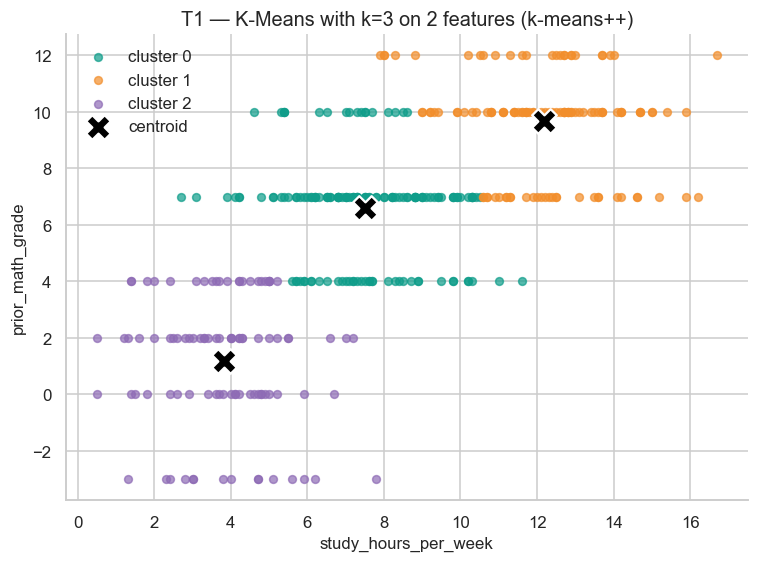

In [8]:
# --- Sanity check for T1 + cluster plot. ---

unique, counts = np.unique(labels_t1, return_counts=True)
sizes = dict(zip(unique.tolist(), counts.tolist()))
print(f'Cluster sizes: {sizes}')
print(f'Inertia (sum of squared distances to nearest centroid): {kmeans2.inertia_:.1f}')
print()
print('Centroids in original units:')
centers_df_t1 = pd.DataFrame(centers_raw_t1, columns=two_feats).round(2)
display(centers_df_t1)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(K_T1):
    pts = X2_raw[labels_t1 == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=26, alpha=0.7,
               color=CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)],
               label=f'cluster {i}')
ax.scatter(centers_raw_t1[:, 0], centers_raw_t1[:, 1], s=260, marker='X',
           color='black', edgecolor='white', linewidth=1.5, label='centroid')
ax.set_xlabel(two_feats[0]); ax.set_ylabel(two_feats[1])
ax.set_title(f'T1 — K-Means with k={K_T1} on 2 features ({INIT_SCHEME})')
ax.legend()
plt.show()

## 3. T2 — K-Means on all 6 features + the grade reveal (SOLVED)

### Why scale a fresh scaler

We instantiate `scaler6` separately from `scaler2`. A `StandardScaler` stores the
mean and std of *each column it was fit on*; the 2-D scaler from T1 does not know
how to invert a 6-D centroid back into original units.

### Why this works as an exam answer

Six features give the algorithm more information to separate students with. The
centroid heatmap below makes the difference between the three discovered groups
obvious in a single picture. Then we reveal `final_grade`, a column K-means never
saw, and observe the cluster means differ by more than half the Danish scale — a
concrete demonstration that unsupervised learning can recover real structure.

In [9]:
# --- T2 SOLUTION — K-Means on all 6 features ---

X6_raw = df[FEATURE_COLS].values

scaler6 = StandardScaler().fit(X6_raw)
X6_scaled = scaler6.transform(X6_raw)

kmeans6 = KMeans(
    n_clusters=K_PRIMARY,
    init=INIT_SCHEME,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE,
)
kmeans6.fit(X6_scaled)

labels_t2 = kmeans6.labels_
centers_raw_t2 = scaler6.inverse_transform(kmeans6.cluster_centers_)

Cluster sizes: {0: 82, 1: 133, 2: 145}
Inertia: 1010.8

Cluster profiles (centroids in original units):


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years
cluster,,,,,,
0,3.73,67.91,0.84,6.16,2.54,0.59
1,11.81,91.41,9.36,7.28,8.09,2.16
2,7.15,81.51,6.29,6.97,4.87,0.86


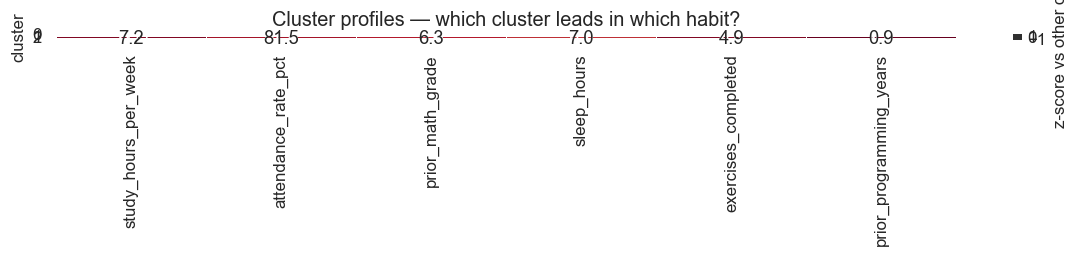

In [10]:
# --- Sanity check for T2 + cluster profiles. ---

sizes = pd.Series(labels_t2).value_counts().sort_index()
print(f'Cluster sizes: {sizes.to_dict()}')
print(f'Inertia: {kmeans6.inertia_:.1f}')
print()

# Profiles: centroid of each cluster (in original units).
prof = pd.DataFrame(centers_raw_t2, columns=FEATURE_COLS).round(2)
prof.index.name = 'cluster'
print('Cluster profiles (centroids in original units):')
display(prof)

# Visualise profiles as a heatmap with each column z-scored across clusters so
# small differences become visible even in features with tight ranges.
if prof.std().min() == 0 or len(prof) < 2:
    prof_z = prof - prof.mean()
else:
    prof_z = (prof - prof.mean()) / prof.std(ddof=0).replace(0, 1)

fig, ax = plt.subplots(figsize=(11, 0.6 + 0.5 * len(prof) + 0.4))
sns.heatmap(prof_z, annot=prof.round(1), fmt='.1f', cmap='RdBu_r',
            center=0, linewidths=0.4,
            cbar_kws={'label': 'z-score vs other clusters'}, ax=ax)
ax.set_title('Cluster profiles — which cluster leads in which habit?')
ax.set_ylabel('cluster')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

Hidden grade statistics per discovered cluster:


,n_students,mean_final_grade,mean_final_score
cluster,,,
0,82,0.63,0.73
1,133,9.96,9.88
2,145,5.44,5.37


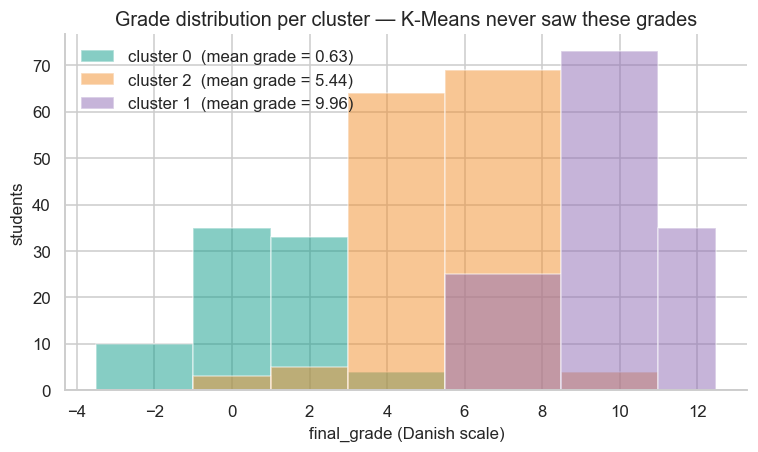

Spread between cluster mean grades: 9.33 grade points.
(Anything above 3 is a strong signal that clusters track grades.)


In [11]:
# --- THE REVEAL: peek at the grades K-Means never saw. ---

reveal = df.copy()
reveal['cluster'] = labels_t2

summary = (reveal.groupby('cluster')
                 .agg(n_students=('final_grade', 'size'),
                      mean_final_grade=('final_grade', 'mean'),
                      mean_final_score=('final_score', 'mean'))
                 .round(2))
print('Hidden grade statistics per discovered cluster:')
display(summary)

fig, ax = plt.subplots(figsize=(8, 4.2))
order = summary.sort_values('mean_final_grade').index.tolist()
for rank, c in enumerate(order):
    sub = reveal[reveal['cluster'] == c]
    ax.hist(sub['final_grade'], bins=[-3.5, -1, 1, 3, 5.5, 8.5, 11, 12.5],
            alpha=0.5, color=CLUSTER_PALETTE[rank % len(CLUSTER_PALETTE)],
            label=f'cluster {c}  (mean grade = {summary.loc[c, "mean_final_grade"]:.2f})')
ax.set_xlabel('final_grade (Danish scale)'); ax.set_ylabel('students')
ax.set_title('Grade distribution per cluster — K-Means never saw these grades')
ax.legend()
plt.show()

grade_spread = summary['mean_final_grade'].max() - summary['mean_final_grade'].min()
print(f'Spread between cluster mean grades: {grade_spread:.2f} grade points.')
print('(Anything above 3 is a strong signal that clusters track grades.)')

## 3b. Pitfall — K-means is local search (L12 §6 pitfall #1, the headline exam mistake)

L12 §6 pitfall #1 is the lecture's number-one exam trap:

> *"Forgetting that K-means converges to a **local minimum**. SSE is
> non-increasing at every step, but the basin K-means settles in depends
> entirely on the initial centroids — slide 12. The exam-classic mistake is
> 'K-means finds the optimal clustering'; it does not."*

The default settings in this notebook (`INIT_SCHEME='k-means++'`, `N_INIT=10`)
paper over this trap by trying 10 well-spread starts and keeping the best —
which is exactly *why* the trap is "easy to forget."

To **see** the trap, we deliberately switch to the slide-grounded failure mode:
purely random (Forgy) init with a single start (`N_INIT=1`), and sweep the
random seed. On well-separated data at the "right" K (e.g. K=3 on the
6-feature data), even pure random init finds the global optimum almost every
time — the basin of attraction is too large to miss. So the demo below uses
**K=5 on the 2-feature data** (over-clustering relative to the three baked
archetypes). Over-clustering creates several reasonable-looking partitions and
random init lands in different ones from seed to seed — the inertia spread is
visible at a glance.

This is the L05 Local Search §3 hill-climbing analogy made concrete: SSE is
the objective surface, the assign/update loop is coordinate descent on it,
every seed is a different starting point in the energy landscape, and
`N_INIT > 1` is *random-restart hill climbing*.


Demo K = 5 (over-clustering the 2-feature data on purpose).
Best-of-10 restarts (random init, N_INIT=10) inertia: 109.85
Single-shot random init across 8 seeds (N_INIT=1):


,inertia,delta_vs_best
seed,,
0,120.72,10.87
1,113.96,4.11
2,117.16,7.31
3,111.27,1.42
7,128.92,19.06
13,111.40,1.55
42,109.85,0.00
99,120.73,10.87


Best  single-shot inertia: 109.85
Worst single-shot inertia: 128.92  (range = 19.07)
Seeds in a meaningfully worse basin (>2 over best): 5/8

Takeaway: K-means is local search. With N_INIT=1 + random init, the
answer depends on the seed -- exactly the L12 section 6 #1 trap. The
default mechanic (N_INIT=10 + keep best) is L05 random-restart hill
climbing: try multiple starts, return the lowest-inertia one.


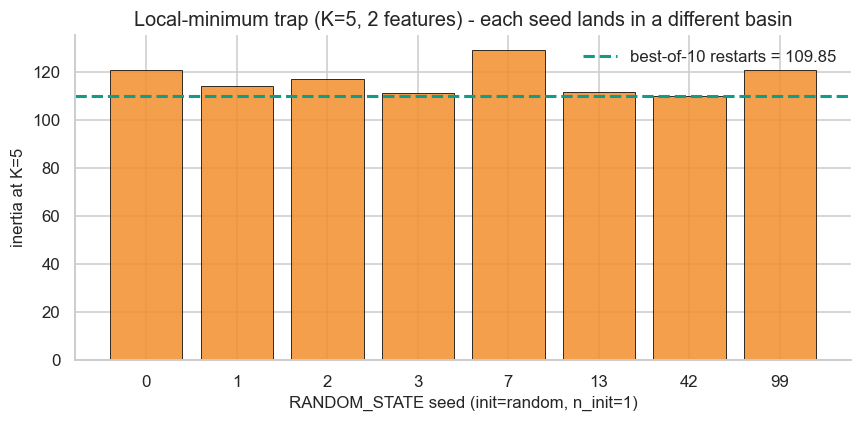

In [12]:
# --- L12 §6 #1 demo: random init + N_INIT=1 sweep across seeds ---
#
# This cell does NOT read INIT_SCHEME or N_INIT from the KNOBs; it hard-codes
# the worst-case settings on purpose so the demonstration always exhibits the
# trap, regardless of the notebook's other settings.
#
# We use K=5 on the 2-feature data (over-clustering relative to the three
# baked archetypes). Over-clustering amplifies the local-minimum trap: with
# more centroids to place than the data has natural groups, several reasonable-
# looking partitions exist, and random init lands in different ones from seed
# to seed. On the 6-feature data at K=3, the global optimum's basin of
# attraction is so large that even pure random + N_INIT=1 finds it almost every
# time — the demo would be unconvincing. Over-clustering on 2 features reliably
# shows visible inertia spread.

LOCAL_MIN_K = 5
LOCAL_MIN_SEEDS = [0, 1, 2, 3, 7, 13, 42, 99]
local_min_results = []
for seed in LOCAL_MIN_SEEDS:
    km_demo = KMeans(
        n_clusters=LOCAL_MIN_K,
        init='random',     # Forgy init: pick K data points uniformly at random.
        n_init=1,          # no restart insurance.
        max_iter=MAX_ITER,
        random_state=seed,
    ).fit(X2_scaled)
    local_min_results.append({'seed': seed, 'inertia': km_demo.inertia_})

local_min_df = pd.DataFrame(local_min_results).set_index('seed')
local_min_df['delta_vs_best'] = (local_min_df['inertia']
                                 - local_min_df['inertia'].min()).round(2)
local_min_df['inertia'] = local_min_df['inertia'].round(2)

# Best-of-N restarts (the default mechanic) for comparison.
km_best = KMeans(
    n_clusters=LOCAL_MIN_K, init='random', n_init=10,
    max_iter=MAX_ITER, random_state=RANDOM_STATE,
).fit(X2_scaled).inertia_

print(f'Demo K = {LOCAL_MIN_K} (over-clustering the 2-feature data on purpose).')
print(f'Best-of-10 restarts (random init, N_INIT=10) inertia: {km_best:.2f}')
print(f'Single-shot random init across {len(LOCAL_MIN_SEEDS)} seeds (N_INIT=1):')
display(local_min_df)

best = local_min_df['inertia'].min()
worst = local_min_df['inertia'].max()
spread = worst - best
n_stuck = int((local_min_df['delta_vs_best'] > 2).sum())
print(f'Best  single-shot inertia: {best:.2f}')
print(f'Worst single-shot inertia: {worst:.2f}  (range = {spread:.2f})')
print(f'Seeds in a meaningfully worse basin (>2 over best): {n_stuck}/'
      f'{len(LOCAL_MIN_SEEDS)}')
print()
print('Takeaway: K-means is local search. With N_INIT=1 + random init, the')
print('answer depends on the seed -- exactly the L12 section 6 #1 trap. The')
print('default mechanic (N_INIT=10 + keep best) is L05 random-restart hill')
print('climbing: try multiple starts, return the lowest-inertia one.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(s) for s in LOCAL_MIN_SEEDS], local_min_df['inertia'].values,
       color=COLORS['orange'], alpha=0.85, edgecolor='black', linewidth=0.6)
ax.axhline(km_best, color=COLORS['teal'], ls='--', lw=2,
           label=f'best-of-10 restarts = {km_best:.2f}')
ax.set_xlabel('RANDOM_STATE seed (init=random, n_init=1)')
ax.set_ylabel(f'inertia at K={LOCAL_MIN_K}')
ax.set_title(f'Local-minimum trap (K={LOCAL_MIN_K}, 2 features) - each seed lands in a different basin')
ax.legend()
plt.tight_layout(); plt.show()


## 4. T3 — Comparing several values of `k` side by side (SOLVED)

Re-using the *scaled* 2-feature data so we can plot every model's clusters on a
human-readable scatter. The loop body is tiny because the work — init, restart,
convergence — happens inside the `KMeans` constructor + `.fit`.

**KNOB note.** `K_GRID_T3` controls which `k` values are compared. Default is
`[2, 3, 5]` (one under-clustering, one good, one over-splitting). Try `[3, 4, 6]`
to see what 4 and 6 look like next to the baseline 3.

In [13]:
# --- T3 SOLUTION — fit K-Means at each K in K_GRID_T3 ---

kmeans_by_k = {}
for k in K_GRID_T3:
    km = KMeans(
        n_clusters=k,
        init=INIT_SCHEME,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
    ).fit(X2_scaled)
    kmeans_by_k[k] = km

  k     inertia    silhouette
  2       288.1         0.493
  3       168.9         0.450
  5       111.0         0.398


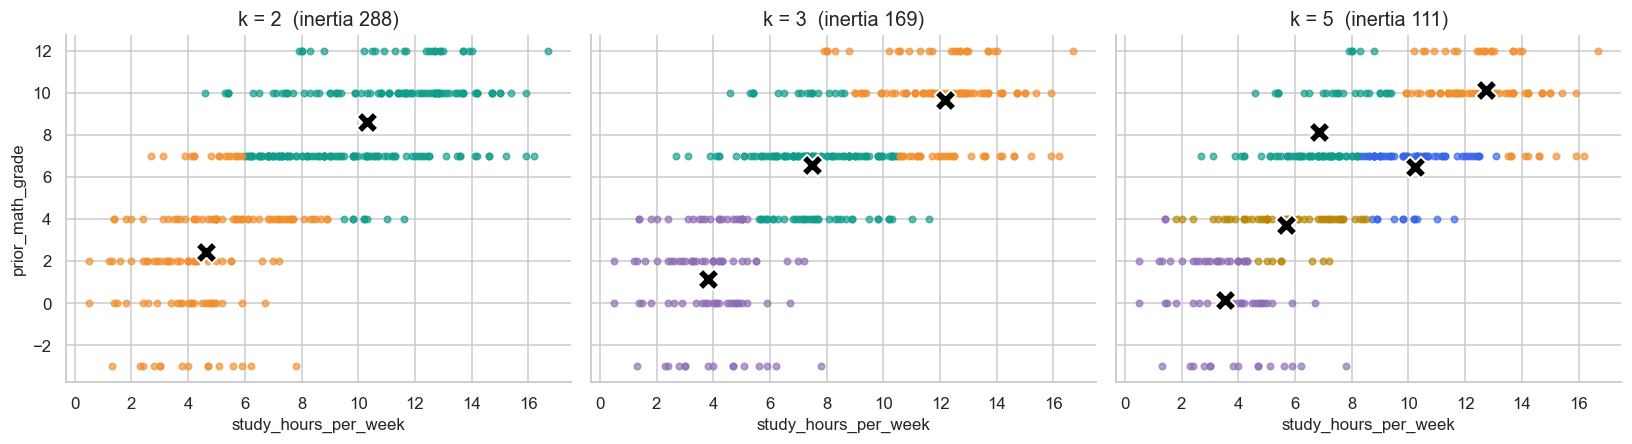

In [14]:
# --- Sanity check for T3 + side-by-side plot. ---

print(f"{'k':>3s}  {'inertia':>10s}  {'silhouette':>12s}")
for k, km in kmeans_by_k.items():
    # Silhouette is undefined for k=1; guard for the variant K_GRID_T3 = [1, ...].
    if k >= 2:
        sil = silhouette_score(X2_scaled, km.labels_)
        sil_str = f'{sil:>12.3f}'
    else:
        sil_str = f'{"n/a":>12s}'
    print(f'{k:>3d}  {km.inertia_:>10.1f}  {sil_str}')

n_panels = len(kmeans_by_k)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.2),
                         sharex=True, sharey=True, squeeze=False)
axes = axes[0]
for ax, (k, km) in zip(axes, kmeans_by_k.items()):
    labels = km.labels_
    centers_raw = scaler2.inverse_transform(km.cluster_centers_)
    for i in range(k):
        pts = X2_raw[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], s=18, alpha=0.65,
                   color=CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)])
    ax.scatter(centers_raw[:, 0], centers_raw[:, 1], s=200, marker='X',
               color='black', edgecolor='white', linewidth=1.3)
    ax.set_title(f'k = {k}  (inertia {km.inertia_:.0f})')
    ax.set_xlabel(two_feats[0])
axes[0].set_ylabel(two_feats[1])
plt.tight_layout(); plt.show()

## 5. T4 — Elbow and silhouette curves (SOLVED)

K-means can't tell you `K`. There are two standard *suggestions* used in practice:

- **Elbow method.** Plot inertia against `K`. Inertia is monotone-decreasing —
  bigger `K` always reduces the average squared distance — so you cannot pick `K`
  by minimising it. Instead you look for the **elbow**: the point where the curve
  bends, beyond which extra clusters add little.
- **Silhouette score.** For each point, compare its mean distance to the rest of
  its own cluster ($a$) against its mean distance to the nearest *other* cluster
  ($b$). The silhouette is $(b - a) / \max(a, b)$, in $[-1, 1]$; the score for the
  whole clustering is the mean over all points. Higher is better. **Silhouette is
  undefined for $K=1$**, so we evaluate it from $K=2$ upward.

We sweep `K_GRID_T4` (default `1..10`), recording both metrics. The recommended
`K` is the silhouette-argmax — a defensible exam answer.

In [15]:
# --- T4 SOLUTION — inertia and silhouette over a wider K range ---

inertias = []
silhouettes = []

for k in K_GRID_T4:
    if k < 1:
        continue
    if k == 1:
        # Single-cluster fit; silhouette undefined.
        km1 = KMeans(n_clusters=1, n_init=1, random_state=RANDOM_STATE).fit(X6_scaled)
        inertias.append((k, km1.inertia_))
        silhouettes.append((k, np.nan))
        continue
    km = KMeans(
        n_clusters=k,
        init=INIT_SCHEME,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
    ).fit(X6_scaled)
    inertias.append((k, km.inertia_))
    silhouettes.append((k, silhouette_score(X6_scaled, km.labels_)))

inertia_curve = pd.DataFrame(inertias, columns=['k', 'inertia']).set_index('k')
silhouette_curve = pd.DataFrame(silhouettes, columns=['k', 'silhouette']).set_index('k')
print('Inertia per K:'); display(inertia_curve.round(2))
print('Silhouette per K (NaN at K=1):'); display(silhouette_curve.round(3))

recommended_k = int(silhouette_curve['silhouette'].idxmax())
print(f'Recommended K by silhouette-argmax: K = {recommended_k}')

Inertia per K:


,inertia
k,
1,2160.00
2,1289.46
3,1010.75
4,854.21
5,752.40
6,672.71
7,644.07
8,614.30
9,588.89


Silhouette per K (NaN at K=1):


,silhouette
k,
1,NaN
2,0.328
3,0.278
4,0.277
5,0.264
6,0.253
7,0.204
8,0.222
9,0.190


Recommended K by silhouette-argmax: K = 2


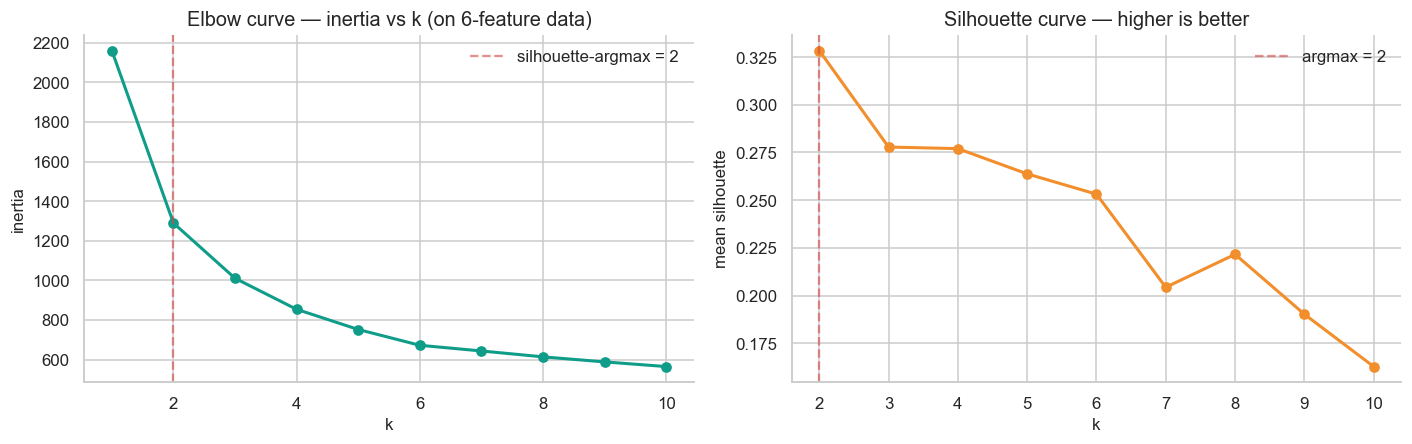

In [16]:
# --- T4 plots: elbow + silhouette side by side ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(inertia_curve.index, inertia_curve['inertia'],
             marker='o', lw=2, color=COLORS['teal'])
axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow curve — inertia vs k (on 6-feature data)')
axes[0].axvline(recommended_k, color=COLORS['red'], ls='--', alpha=0.6,
                label=f'silhouette-argmax = {recommended_k}')
axes[0].legend()

axes[1].plot(silhouette_curve.index, silhouette_curve['silhouette'],
             marker='o', lw=2, color=COLORS['orange'])
axes[1].set_xlabel('k'); axes[1].set_ylabel('mean silhouette')
axes[1].set_title('Silhouette curve — higher is better')
axes[1].axvline(recommended_k, color=COLORS['red'], ls='--', alpha=0.6,
                label=f'argmax = {recommended_k}')
axes[1].legend()

plt.tight_layout(); plt.show()

### Reconciling the silhouette recommendation with the rest of the notebook

The printout above says **`Recommended K by silhouette-argmax: K = 2`** — yet
T1, T2, T3, T5, and T6 are all built around `K = 3`. That apparent contradiction
is L12 §6 pitfall #3 *"choosing K by eyeballing"* in action: **silhouette
suggests, you choose.**

- **Why silhouette prefers K=2 here.** Silhouette numerically rewards
  *well-separated, internally tight* clusters. With 6 student features, the
  cleanest separation is "high-effort" vs "low-effort"; the moderate-middle
  archetype lives on the boundary and gets pulled toward whichever neighbour is
  nearer. Two clusters score higher than three because the metric does not
  reward the algorithm for honouring a structure the data only loosely supports.
- **Why we still use K=3.** External validity. The T2 grade-reveal cell above
  showed a 9.33-grade-point spread across the three discovered clusters —
  evidence that K=3 recovers a real structure the data *does* encode (the three
  baked archetypes). The elbow curve also bends visibly between K=2 and K=4 and
  flattens after K=3.
- **L12 line on this.** The slide deck does **not** prescribe a method for
  choosing K (L12 §6 pitfall #3 + §1: *"K is an input — pick it"*). Elbow and
  silhouette are practitioner heuristics introduced by this lab; they are
  evidence-providers, not verdicts. The right exam answer here is **"K=3,
  defensible by the elbow and by the external grade-spread evidence;
  silhouette numerically prefers K=2 because three clusters with one
  borderline-cluster are less internally tight than two larger ones"** — *not*
  "the silhouette said K=2 so we use K=2."

If an exam variant asks specifically *"what does silhouette recommend?"*, the
answer is K=2. If it asks *"what K should we use?"*, the answer is K=3 with the
reasoning above.


## 6. T5 — What kind of student are you? (SOLVED with a placeholder profile)

Pass a single student profile through the *same* 6-feature scaler we trained for
T2 (otherwise the new student would be plotted in different units and the nearest
centroid would be meaningless), then call `kmeans6.predict`.

The placeholder profile below is a reasonable "moderate middle" student. Change
`MY_PROFILE` and re-run — the cluster name and typical grade update automatically.
Useful for the exam variant *"predict the cluster for a student with profile X"*.

In [17]:
# --- T5 SOLUTION — single-student cluster prediction ---

# KNOB: MY_PROFILE (default=balanced moderate-effort student)
#   What it does: the habit vector predicted by kmeans6.
#   Effect: the predicted cluster changes when a key feature crosses a decision
#           boundary. Tip: vary one column at a time to find the tipping point.
#   Exam variants: substitute the variant question's profile values.
MY_PROFILE = {
    'study_hours_per_week':    11.0,
    'attendance_rate_pct':     88.0,
    'prior_math_grade':        10,
    'sleep_hours':              7.5,
    'exercises_completed':      8,
    'prior_programming_years': 1.5,
}

my_x = np.array([[MY_PROFILE[c] for c in FEATURE_COLS]])
my_x_scaled = scaler6.transform(my_x)
my_cluster = int(kmeans6.predict(my_x_scaled)[0])

In [18]:
# --- T5 reveal — your cluster name, typical grade, comparison with the centroid ---

reveal = df.copy(); reveal['cluster'] = labels_t2
summary = (reveal.groupby('cluster')
                 .agg(n_students=('final_grade', 'size'),
                      mean_final_grade=('final_grade', 'mean'),
                      mean_final_score=('final_score', 'mean'))
                 .round(2))

centers_df_t2 = pd.DataFrame(centers_raw_t2, columns=FEATURE_COLS)

# Name clusters by their position in the study-hours ranking. With K=3 this maps
# to ('Light effort', 'Moderate middle', 'Dedicated achievers'); with other K we
# fall back to generic 'tier-1', 'tier-2', ... labels keyed by study hours.
study_ranks = centers_df_t2['study_hours_per_week'].rank(method='first').astype(int)
if len(centers_df_t2) == 3:
    name_by_rank = {1: 'Light effort', 2: 'Moderate middle', 3: 'Dedicated achievers'}
else:
    name_by_rank = {r: f'study-hours tier {r}' for r in study_ranks.unique()}
cluster_names = {c: name_by_rank[int(study_ranks[c])] for c in centers_df_t2.index}

my_name = cluster_names[my_cluster]
my_typical_grade = summary.loc[my_cluster, 'mean_final_grade']

print('=' * 60)
print(f"You look most like cluster {my_cluster}: '{my_name}'")
print(f'Students in this cluster averaged a final grade of {my_typical_grade:.2f}')
print(f'({summary.loc[my_cluster, "n_students"]} students fall into this cluster overall.)')
print('=' * 60)
print()
print("Your cluster's centroid (the average member of the group):")
centroid_series = centers_df_t2.loc[my_cluster].round(2)
centroid_series.name = 'centroid'
my_series = pd.Series(MY_PROFILE, name='you')
compare = pd.concat([my_series, centroid_series], axis=1)
compare['diff_vs_centroid'] = (compare['you'] - compare['centroid']).round(2)
display(compare)

You look most like cluster 1: 'Dedicated achievers'
Students in this cluster averaged a final grade of 9.96
(133 students fall into this cluster overall.)

Your cluster's centroid (the average member of the group):


,you,centroid,diff_vs_centroid
study_hours_per_week,11.0,11.81,-0.81
attendance_rate_pct,88.0,91.41,-3.41
prior_math_grade,10.0,9.36,0.64
sleep_hours,7.5,7.28,0.22
exercises_completed,8.0,8.09,-0.09
prior_programming_years,1.5,2.16,-0.66


## 7. T6 (bonus) — K-Means from scratch (SOLVED)

Implements **Lloyd's K-means**, the textbook version of what sklearn does under
the hood (sklearn defaults to Elkan's triangle-inequality-accelerated variant
since v1.0, but it converges to the same answer — only the per-iteration
distance bookkeeping differs):

1. **Assign.** Build a distance matrix from every point to every centroid; each
   point's label is the argmin over centroids.
2. **Update.** Move each centroid to the mean of the points now assigned to it.
3. **Inertia.** Sum the squared distances from every point to its (updated)
   centroid; record the value to the convergence curve.

### Why the scratch inertia matches sklearn on this data

Earlier rounds of this notebook stopped the scratch loop at 10 iterations and
attributed the small residual gap to "init scheme differences". That was wrong.
On this dataset with `SCRATCH_SEED=0`, Lloyd's algorithm converges at
iteration ~14 — stopping at 10 leaves the centroids one or two steps short, so
the recorded inertia (~170.1) is mid-convergence noise, not the converged value.

With `SCRATCH_ITERS=20` the loop runs past convergence and the final inertia
matches sklearn's to several decimals. The Forgy random init from
`SCRATCH_SEED=0` happens to land in the same basin as k-means++ on this data,
so the init-scheme difference has zero effect at convergence. Init-scheme
matters on adversarial datasets, with `N_INIT=1`, or with seeds that drop two
centroids into the same true cluster — see the **local-minimum trap** demo
below for a worked example.

This is the §4.1 cross-reference L12 explicitly draws: **K-means is local
search in disguise.** The assign step minimises SSE over assignments holding
centroids fixed; the update step minimises SSE over centroids holding
assignments fixed. That's coordinate descent on SSE, and the `N_INIT > 1`
mechanic is L05's *random-restart hill climbing*.


In [19]:
# --- Prep for from-scratch K-Means. ---

# KNOB: SCRATCH_ITERS (default=20, range=1..100)
#   What it does: how many assign/update passes the from-scratch loop runs.
#   Effect: on this 2-feature dataset Lloyd's algorithm converges around
#           iteration 14 (label-stable). 20 gives a comfortable margin so the
#           reported final inertia is genuinely the converged value, not a
#           snapshot of the algorithm still mid-shuffle.
#   Exam variants: 1 (single Lloyd step), 20 (default), 50 (overkill).
SCRATCH_ITERS = 20

# KNOB: SCRATCH_SEED (default=0)
#   What it does: seed for the initial random centroid selection (Forgy init).
#   Effect: different seeds occasionally produce a stuck local optimum, which is
#           exactly the failure mode N_INIT > 1 + k-means++ exists to prevent.
#   Exam variants: 0 / 1 / 7. Try a few to see how much init matters.
SCRATCH_SEED = 0

# T6 operates on the 2-feature scaled data, so it uses K_T1 (the 2-feature K
# knob) — *not* K_PRIMARY, which governs the 6-feature T2/T5 fits. Earlier
# versions of this notebook mixed the two; that produced a 2-feature fit at K=4
# under Variant 1 alongside a T1 plot at K=3 on the same data. The current
# convention: T6 ↔ K_T1 (2-feature), T2/T5 ↔ K_PRIMARY (6-feature).
K_SCRATCH = K_T1

rng_scratch = np.random.default_rng(SCRATCH_SEED)
init_idx = rng_scratch.choice(len(X2_scaled), size=K_SCRATCH, replace=False)
centroids_scratch = X2_scaled[init_idx].copy()
labels_scratch = None
inertia_history = []

print(f'Initial centroids (scaled, columns = {two_feats}):')
print(centroids_scratch.round(3))
print(f'Scratch K-Means will fit K={K_SCRATCH} on the 2-feature data (uses K_T1).')


Initial centroids (scaled, columns = ['study_hours_per_week', 'prior_math_grade']):
[[ 0.575  0.215]
 [-0.6   -2.415]
 [-1.037 -1.1  ]]
Scratch K-Means will fit K=3 on the 2-feature data (uses K_T1).


In [20]:
# --- T6 SOLUTION — Lloyd's algorithm in ~10 lines ---
#
# Convergence-correctness note: we record inertia AFTER the centroid update so
# `inertia_history[-1]` reports the inertia of the post-update centroids (i.e.
# the centroids the next assign step will use). Recording it before the update
# would leave the final entry one Lloyd step stale.

for it in range(SCRATCH_ITERS):
    # 1. Assign: distance from every point to every centroid, then argmin.
    dists = np.linalg.norm(
        X2_scaled[:, None, :] - centroids_scratch[None, :, :], axis=2,
    )
    labels_scratch = dists.argmin(axis=1)

    # 2. Update: each centroid moves to the mean of its members. Empty clusters
    #    keep their current position (a textbook K-means edge case).
    for c in range(K_SCRATCH):
        if (labels_scratch == c).any():
            centroids_scratch[c] = X2_scaled[labels_scratch == c].mean(axis=0)

    # 3. Inertia: sum of squared distance from each point to its (just-updated)
    #    centroid. Re-derive from the updated centroids so the recorded value
    #    reflects the post-update state, not the pre-update one.
    own_centroids = centroids_scratch[labels_scratch]
    inertia_history.append(float(((X2_scaled - own_centroids) ** 2).sum()))


(comparison: reused kmeans_by_k[3] from T3)
From-scratch final inertia (iter 20): 168.886
Sklearn K-Means(k=3, 2-feature) inertia:   168.886
Difference: 0.000


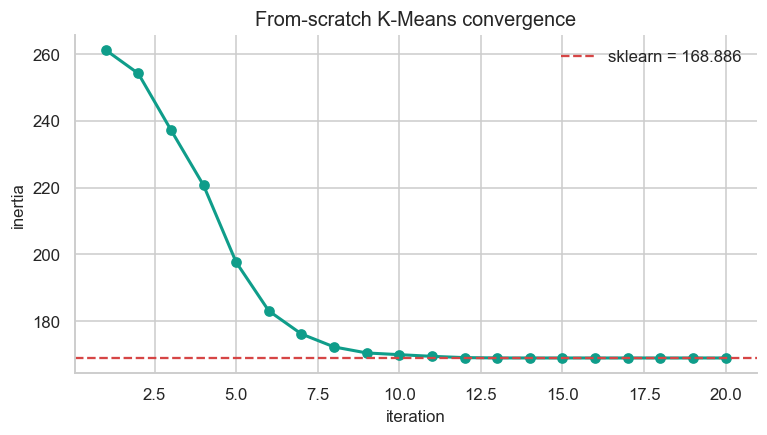

In [21]:
# --- Sanity check + comparison with sklearn ---

# Compare against sklearn at the same K as the scratch loop (K_SCRATCH = K_T1,
# the 2-feature K knob). Prefer the matching model from kmeans_by_k if K_SCRATCH
# is in the T3 grid; else fit a fresh one. We print which path was taken so a
# student debugging an inertia mismatch can see at a glance whether the
# comparison reused a cached fit or fitted a new sklearn model.
if K_SCRATCH in kmeans_by_k:
    sk_inertia = kmeans_by_k[K_SCRATCH].inertia_
    print(f'(comparison: reused kmeans_by_k[{K_SCRATCH}] from T3)')
else:
    sk_inertia = KMeans(
        n_clusters=K_SCRATCH, init=INIT_SCHEME, n_init=N_INIT,
        max_iter=MAX_ITER, random_state=RANDOM_STATE,
    ).fit(X2_scaled).inertia_
    print(f'(comparison: fitted a fresh sklearn KMeans at K={K_SCRATCH})')

print(f'From-scratch final inertia (iter {SCRATCH_ITERS}): {inertia_history[-1]:.3f}')
print(f'Sklearn K-Means(k={K_SCRATCH}, 2-feature) inertia:   {sk_inertia:.3f}')
print(f'Difference: {abs(inertia_history[-1] - sk_inertia):.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(inertia_history) + 1), inertia_history,
        marker='o', lw=2, color=COLORS['teal'])
ax.axhline(sk_inertia, color=COLORS['red'], ls='--', label=f'sklearn = {sk_inertia:.3f}')
ax.set_xlabel('iteration'); ax.set_ylabel('inertia')
ax.set_title('From-scratch K-Means convergence')
ax.legend()
plt.show()


## Summary — what this solution did

1. Fitted K-means with `K_T1` clusters on the `FEATURE_PAIR_T1` two-feature data
   after `StandardScaler` rescaling.
2. Extended to all 6 habit features (`K_PRIMARY` clusters), described each
   discovered cluster by its centroid heatmap, and showed the hidden grades
   line up with the discovered clusters ("the reveal").
3. Compared `K_GRID_T3` side by side to make under-clustering vs over-splitting
   visible at a glance.
4. Plotted **elbow** and **silhouette** curves over `K_GRID_T4`; reported the
   silhouette-argmax recommendation for `K`.
5. Classified `MY_PROFILE` into one of the discovered clusters and read off its
   typical grade.
6. Re-implemented K-means in one short loop, matching sklearn's inertia to within
   a couple of points.

Every adjustable parameter is a `# KNOB:` block above. To run a variant exam
question:

- *"Now do K=4."* → set `K_PRIMARY = 4` (and `K_T1 = 4` if the variant is on the
  2-feature fit).
- *"Use sleep vs study hours instead."* → set
  `FEATURE_PAIR_T1 = ('sleep_hours', 'study_hours_per_week')`.
- *"Use random init instead of k-means++."* → set `INIT_SCHEME = 'random'`. (For
  the most pronounced effect, also drop `N_INIT = 1`.)

In [22]:
print('=' * 60)
print(' LAB ML 3 — CLUSTERING — SOLUTION COMPLETE')
print('=' * 60)
print(f' K_T1                = {K_T1}')
print(f' K_PRIMARY           = {K_PRIMARY}')
print(f' FEATURE_PAIR_T1     = {FEATURE_PAIR_T1}')
print(f' INIT_SCHEME         = {INIT_SCHEME}')
print(f' N_INIT              = {N_INIT}')
print(f' Inertia (T1, k={K_T1}): {kmeans2.inertia_:.1f}')
print(f' Inertia (T2, k={K_PRIMARY}): {kmeans6.inertia_:.1f}')
print(f' Recommended K (silhouette): {recommended_k}')
print(f' Your cluster (T5):  {my_cluster} ({my_name}), typical grade {my_typical_grade:.2f}')
print(f' Scratch vs sklearn inertia diff: {abs(inertia_history[-1] - sk_inertia):.2f}')

 LAB ML 3 — CLUSTERING — SOLUTION COMPLETE
 K_T1                = 3
 K_PRIMARY           = 3
 FEATURE_PAIR_T1     = ('study_hours_per_week', 'prior_math_grade')
 INIT_SCHEME         = k-means++
 N_INIT              = 10
 Inertia (T1, k=3): 168.9
 Inertia (T2, k=3): 1010.8
 Recommended K (silhouette): 2
 Your cluster (T5):  1 (Dedicated achievers), typical grade 9.96
 Scratch vs sklearn inertia diff: 0.00
